# 코호트 분석 및 Retention 측정

## 분석 목적
첫 세션에서 노출된 콘텐츠 품질이 사용자 retention에 미치는 영향 분석

## 핵심 가설
- 첫 세션 품질이 높은 사용자 일수록 D7 retention이 높다.
- 세그먼트별 retention 패턴이 다르다.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform

# 한글 폰트 설정
if platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

df_events = pd.read_csv('events.csv')
df_users = pd.read_csv('users.csv')

## 사용자별 첫 세션 날짜 및 품질 확인

In [30]:
first_session = df_events.groupby('user_id')['event_date'].min().reset_index()
first_session.columns = ['user_id', 'first_date']
print(first_session.head())

    user_id  first_date
0  USR_0000  2023-12-02
1  USR_0001  2023-03-02
2  USR_0002  2023-12-26
3  USR_0003  2023-04-08
4  USR_0004  2023-08-25


In [31]:
first_session_events = df_events.merge(first_session, on='user_id')
first_session_events = first_session_events[
    first_session_events['event_date'] == first_session_events['first_date']
]
print(first_session_events.shape)

(6144, 10)


In [32]:
first_quality = first_session_events.groupby('user_id')['content_quality_score'].mean().reset_index()
first_quality.columns = ['user_id', 'first_session_quality']
print(first_quality.head())

    user_id  first_session_quality
0  USR_0000               0.423450
1  USR_0001               0.509138
2  USR_0002               0.466122
3  USR_0003               0.413717
4  USR_0004               0.434075


In [33]:
quality_mean = first_quality['first_session_quality'].mean()
print(quality_mean)

0.49304224578085315


In [34]:
first_quality['quality_group'] = np.where(
    first_quality['first_session_quality'] >= quality_mean,
    '고품질 그룹',
    '저품질 그룹'
)
print(first_quality['quality_group'].value_counts())

quality_group
고품질 그룹    507
저품질 그룹    493
Name: count, dtype: int64


## D7 Retention 계산

In [35]:
df_events['event_date'] = pd.to_datetime(df_events['event_date'])
first_session['first_date'] = pd.to_datetime(first_session['first_date'])

In [36]:
df_retention = df_events.merge(first_session, on='user_id')
df_retention['days_since_first'] = (
    df_retention['event_date'] - df_retention['first_date']
).dt.days

print(df_retention[['user_id', 'event_date', 'first_date', 'days_since_first']].head())

    user_id event_date first_date  days_since_first
0  USR_0000 2023-12-02 2023-12-02                 0
1  USR_0000 2023-12-02 2023-12-02                 0
2  USR_0000 2023-12-02 2023-12-02                 0
3  USR_0000 2023-12-02 2023-12-02                 0
4  USR_0000 2023-12-27 2023-12-02                25


In [37]:
d7 = df_retention[df_retention['days_since_first'].between(1, 7)]['user_id'].unique()

first_quality['D7_retention'] = first_quality['user_id'].isin(d7)

print(first_quality['D7_retention'].value_counts())

D7_retention
False    699
True     301
Name: count, dtype: int64


## 세그먼트별 첫 세션 품질 확인

In [38]:
segment_quality = first_quality.merge(df_users, on='user_id')
print(segment_quality.groupby('segment')['first_session_quality'].mean().round(3))

segment
at_risk    0.488
casual     0.497
churned    0.487
power      0.509
Name: first_session_quality, dtype: float64


In [39]:
d7_by_group = first_quality.groupby('quality_group')['D7_retention'].mean() * 100
print(d7_by_group.round(1))

quality_group
고품질 그룹    33.7
저품질 그룹    26.4
Name: D7_retention, dtype: float64


## 첫 세션 품질 그룹별 D7 Retention 비교

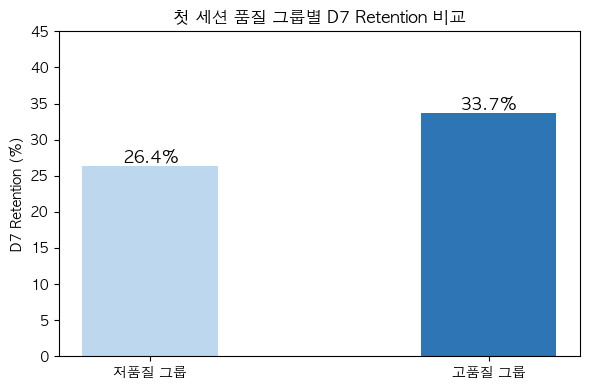

In [40]:
import matplotlib.pyplot as plt

groups = ['저품질 그룹', '고품질 그룹']
values = [26.4, 33.7]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(groups, values, color=['#BDD7EE', '#2E75B6'], width=0.4)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val}%',
            ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('D7 Retention (%)')
ax.set_title('첫 세션 품질 그룹별 D7 Retention 비교')
ax.set_ylim(0, 45)
plt.tight_layout()
plt.show()

## 핵심 인사이트
- 고품질 콘텐츠를 첫 세션에서 본 사용자의 D7 Retention = 33.7%
- 저품질 콘텐츠를 첫 세션에서 본 사용자의 D7 Retention = 26.4%
- 차이 = 7.3%p

## 서비스 액션
신규 유저의 첫 피드에 고품질 콘텐츠를 우선 노출하는 추천 정책 적용 필요

## 세그먼트별 D7 Retention 비교

In [41]:
segment_retention = segment_quality.groupby('segment')['D7_retention'].mean() * 100

print(segment_retention.round(1))

segment
at_risk    20.7
casual     47.6
churned     0.0
power      75.0
Name: D7_retention, dtype: float64


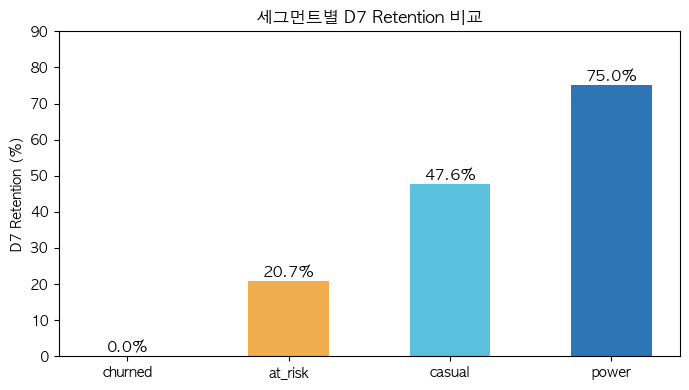

In [42]:
fig, ax = plt.subplots(figsize=(7, 4))

segments = ['churned', 'at_risk', 'casual', 'power']
values = [segment_retention[s] for s in segments]
colors = ['#D9534F', '#F0AD4E', '#5BC0DE', '#2E75B6']

bars = ax.bar(segments, values, color=colors, width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{val:.1f}%',
            ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('D7 Retention (%)')
ax.set_title('세그먼트별 D7 Retention 비교')
ax.set_ylim(0, 90)
plt.tight_layout()
plt.show()

## 핵심 인사이트
- power user D7 retention 75.0% → 핵심 유지 대상
- casual user D7 retention 47.6% → power user로 전환 가능성 있음
- at_risk user D7 retention 20.7% → 이탈 방어 전략 필요
- churned user D7 retention 0.0% → 재유입 캠페인 필요

## 서비스 액션
- at_risk user 대상 → 고품질 콘텐츠 푸시 알림으로 재방문 유도
- casual user 대상 → 개인화 추천 강화로 power user 전환 유도